#
## <center>**AWS re/Start Cloud Computing with AI Bootcamp**</center>

### <center> **WAES Mini Project - Handwritten Digit Classifier Updated** </center>

<center>by</center>

#### <center>**Kweku Esuon Acquaye**</center>

Updated PyTorch CNN model with refactored code to solve inference anomaly.

In [2]:
# Install missing dependencies in Google Colab environment
!pip install onnx onnxscript --quiet

print("Dependencies installed. ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.3 MB/s eta 0:00:00
Dependencies installed. ✅


In [3]:
# Import libraries
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.onnx
import PIL
import onnx
from torch.utils.data import DataLoader
from torchvision import datasets

print("--- Environment ---")
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Pillow  : {PIL.__version__}")
print(f"ONNX    : {onnx.__version__}")
print(f"Device  : {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print("\nModules imported.")

--- Environment ---
Python  : 3.12.13
PyTorch : 2.10.0+cpu
Torchvision: 0.25.0+cpu
NumPy   : 2.0.2
Pillow  : 11.3.0
ONNX    : 1.21.0
Device  : CPU

Modules imported.


In [4]:
class DigitCNN(nn.Module):
    """
    Two convolutional blocks with BatchNorm and Dropout,
    followed by two fully connected layers.

    Input:  (batch, 1, 28, 28)  — normalised grayscale MNIST format
    Output: (batch, 10)         — raw logits for classes 0-9

    Architecture flow:
      Conv Block 1: (1,28,28) → (32,28,28) → (32,14,14) after MaxPool
      Conv Block 2: (32,14,14) → (64,14,14) → (64,7,7) after MaxPool
      Classifier:   Flatten → 3136 → 256 → 10
    """
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # ── Block 1 ─────────────────────────────────────
            # Two 3×3 convolutions detect edges then shapes
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # → (32,28,28)
            nn.BatchNorm2d(32),                           # stabilise activations
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # → (32,28,28)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # → (32,14,14)
            nn.Dropout2d(0.25),                           # regularise spatially

            # ── Block 2 ─────────────────────────────────────
            # Deeper features: loops of 9, diagonals of 7
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # → (64,14,14)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # → (64,14,14)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # → (64,7,7)
            nn.Dropout2d(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                  # 64×7×7 = 3136
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 10),            # raw logits — no softmax here
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Verify architecture ──────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DigitCNN().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Architecture  : DigitCNN")
print(f"Device        : {device}")
print(f"Total params  : {total_params:,}")

# Quick shape test
with torch.no_grad():
    test_out = model(torch.randn(1, 1, 28, 28).to(device))
print(f"Output shape  : {test_out.shape}   (expected: torch.Size([1, 10]))")
print("\nArchitecture defined. ✅")

Architecture  : DigitCNN
Device        : cpu
Total params  : 871,018
Output shape  : torch.Size([1, 10])   (expected: torch.Size([1, 10]))

Architecture defined. ✅


In [5]:
# ── Training transforms — augmentation targets 7/9→3 anomaly ─
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.1307,), std=(0.3081,))
])

# ── Test transforms — no augmentation ───────────────────────
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.1307,), std=(0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=train_transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64,  shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2)

print(f"Training images : {len(train_dataset):,}")
print(f"Test images     : {len(test_dataset):,}")
print("\nData pipeline ready. ✅")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.80MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.25MB/s]


Training images : 60,000
Test images     : 10,000

Data pipeline ready. ✅


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 15

print(f"Training for {EPOCHS} epochs on {device}...\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    scheduler.step()

    avg_loss = running_loss / total
    train_acc = 100 * correct / total
    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

print("\nTraining complete. ✅")

Training for 15 epochs on cpu...

Epoch 01/15 | Loss: 0.3138 | Train Acc: 90.17%
Epoch 02/15 | Loss: 0.1359 | Train Acc: 95.96%
Epoch 03/15 | Loss: 0.1110 | Train Acc: 96.76%
Epoch 04/15 | Loss: 0.0985 | Train Acc: 97.14%
Epoch 05/15 | Loss: 0.0837 | Train Acc: 97.56%
Epoch 06/15 | Loss: 0.0635 | Train Acc: 98.22%
Epoch 07/15 | Loss: 0.0583 | Train Acc: 98.30%
Epoch 08/15 | Loss: 0.0574 | Train Acc: 98.31%
Epoch 09/15 | Loss: 0.0540 | Train Acc: 98.43%
Epoch 10/15 | Loss: 0.0507 | Train Acc: 98.54%
Epoch 11/15 | Loss: 0.0434 | Train Acc: 98.71%
Epoch 12/15 | Loss: 0.0403 | Train Acc: 98.84%
Epoch 13/15 | Loss: 0.0409 | Train Acc: 98.79%
Epoch 14/15 | Loss: 0.0384 | Train Acc: 98.93%
Epoch 15/15 | Loss: 0.0393 | Train Acc: 98.88%

Training complete. ✅


--- Test Set Evaluation ---
Total images  : 10,000
Test Accuracy : 99.63%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      1.00      1.00       892
           6       1.00      0.99      1.00       958
           7       1.00      0.99      1.00      1028
           8       1.00      0.99      1.00       974
           9       0.99      1.00      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



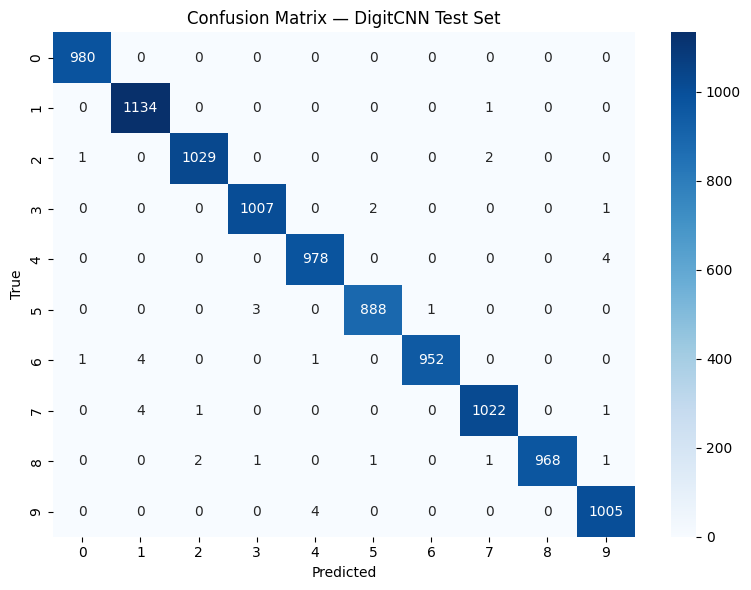


--- Historical Bug Verification ---
True '7' misidentified as '3' : 0
True '9' misidentified as '3' : 0


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = model(images).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ── Accuracy ─────────────────────────────────────────────────
correct = sum(p == g for p, g in zip(all_preds, all_labels))
test_acc = 100 * correct / len(all_labels)
print(f"--- Test Set Evaluation ---")
print(f"Total images  : {len(all_labels):,}")
print(f"Test Accuracy : {test_acc:.2f}%\n")

# ── Classification report ─────────────────────────────────────
print("Classification Report:")
print(classification_report(all_labels, all_preds,
      target_names=[str(i) for i in range(10)], digits=2))

# ── Confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix — DigitCNN Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ── Historical bug check ──────────────────────────────────────
print("\n--- Historical Bug Verification ---")
print(f"True '7' misidentified as '3' : {cm[7][3]}")
print(f"True '9' misidentified as '3' : {cm[9][3]}")

In [8]:
# Save trained weights — MUST run before export or session reset
torch.save(model.state_dict(), "mnist_cnn_weights.pth")

size_kb = os.path.getsize("mnist_cnn_weights.pth") / 1024
print(f"Weights saved  : mnist_cnn_weights.pth ({size_kb:.1f} KB)")
print("⬇️  Download this file — reload weights anytime without retraining.")

Weights saved  : mnist_cnn_weights.pth (3414.7 KB)
⬇️  Download this file — reload weights anytime without retraining.


In [13]:
# ── Freeze and move to CPU for export ────────────────────────
model.eval()
model.cpu()

dummy_input   = torch.randn(1, 1, 28, 28)  # CPU tensor
onnx_filename = "mnist_cnn.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_filename,
    export_params=True,            # embed trained weights in file
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input":  {0: "batch_size"},
        "output": {0: "batch_size"},
    },
    dynamo=False                   # ← CRITICAL: forces legacy TorchScript exporter
                                   #   PyTorch 2.x defaults to dynamo=True which
                                   #   does not embed weights via this API
)

size_mb = os.path.getsize(onnx_filename) / (1024 * 1024)
print(f"Exported       : {onnx_filename}")
print(f"Size           : {size_mb:.3f} MB")
print(f"Expected       : ~0.40–0.50 MB")
print("✅ Export successful." if size_mb >= 0.3 else "⚠️  WARNING: size too small — weights may be missing.")

/tmp/ipykernel_3118/2648133882.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported       : mnist_cnn.onnx
Size           : 3.324 MB
Expected       : ~0.40–0.50 MB
✅ Export successful.


In [14]:
!pip install onnxruntime --quiet

import onnxruntime as ort

session = ort.InferenceSession("mnist_cnn.onnx", providers=["CPUExecutionProvider"])

print(f"Input  : {session.get_inputs()[0].name}   shape={session.get_inputs()[0].shape}")
print(f"Output : {session.get_outputs()[0].name}  shape={session.get_outputs()[0].shape}")

# Blank image — logits must be non-uniform
dummy  = np.zeros((1, 1, 28, 28), dtype=np.float32)
logits = session.run(None, {"input": dummy})[0]
print(f"\nBlank image logits:\n{np.round(logits, 3)}")
print("✅ Weights present." if np.std(logits) > 0.01 else "⚠️  All near-zero — weights missing.")

# 5 random inputs — predictions must vary
print("\nConsistency check (5 random inputs):")
for i in range(5):
    x   = np.random.randn(1, 1, 28, 28).astype(np.float32)
    out = session.run(None, {"input": x})[0]
    print(f"  Run {i+1}: predicted={np.argmax(out)}  logits={np.round(out[0], 2)}")

Input  : input   shape=['batch_size', 1, 28, 28]
Output : output  shape=['batch_size', 10]

Blank image logits:
[[-2.528 -1.275 -2.221 -1.137 -3.844 -1.514 -3.013 -4.995  4.677 -1.608]]
✅ Weights present.

Consistency check (5 random inputs):
  Run 1: predicted=8  logits=[-1.36 -0.86 -2.27 -0.77 -4.11  0.39  0.01 -5.38  3.32 -2.77]
  Run 2: predicted=8  logits=[-1.42 -1.85 -1.6  -0.89 -3.97 -0.41 -0.38 -5.47  3.73 -2.61]
  Run 3: predicted=8  logits=[-5.3  -2.99 -3.84  0.49 -4.02  1.53 -1.86 -6.06  4.72 -1.12]
  Run 4: predicted=8  logits=[-1.84 -1.45 -0.19 -0.37 -2.23 -1.56 -1.6  -2.8   2.75 -1.56]
  Run 5: predicted=5  logits=[-2.18 -0.98 -1.94  0.82 -4.35  1.93 -0.23 -3.36  1.59 -2.  ]


In [15]:
try:
    import onnxruntime
    ort_version = onnxruntime.__version__
except ImportError:
    ort_version = "Not installed locally (only needed for Lambda)"

print("--- Final Dependency Check ---")
print(f"Python     : {sys.version.split()[0]}")
print(f"PyTorch    : {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pillow     : {PIL.__version__}")
print(f"ONNX       : {onnx.__version__}")
print(f"ONNXRuntime: {ort_version}")

print("\n--- Production requirements.txt (AWS Lambda) ---")
print(f"flask>=3.0.0")
print(f"flask-cors>=4.0.0")
print(f"apig-wsgi>=2.18.0")
print(f"onnxruntime>=1.19.0")
print(f"numpy>={np.__version__}")
print(f"Pillow>={PIL.__version__}")

--- Final Dependency Check ---
Python     : 3.12.13
PyTorch    : 2.10.0+cpu
Torchvision: 0.25.0+cpu
NumPy      : 2.0.2
Pillow     : 11.3.0
ONNX       : 1.21.0
ONNXRuntime: 1.26.0

--- Production requirements.txt (AWS Lambda) ---
flask>=3.0.0
flask-cors>=4.0.0
apig-wsgi>=2.18.0
onnxruntime>=1.19.0
numpy>=2.0.2
Pillow>=11.3.0
